<a href="https://colab.research.google.com/github/ijuzu/DL_Task1_Image_Segmentation/blob/main/Image%20Segmentation%20Model%20(ResNet50%20implementation%20before%20trying%20Unet).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Author: Ieva Juzumaitė
# LSP: 2525057

In [ ]:
import subprocess
subprocess.run(["pip", "install", "fiftyone", "-q"], check=True)

CompletedProcess(args=['pip', 'install', 'fiftyone', '-q'], returncode=0)

In [ ]:
import os
import json
import numpy as np
import cv2
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as torch_F
from torch.utils.data import Dataset, DataLoader
from torchvision import models
import torchvision.transforms.functional as F
import torchvision.transforms as T
from PIL import Image
from sklearn.metrics import precision_score, recall_score, f1_score, \
                            confusion_matrix, ConfusionMatrixDisplay

import fiftyone.zoo as foz

/usr/local/lib/python3.12/dist-packages/glob2/fnmatch.py:141: SyntaxWarning: invalid escape sequence '\Z'
  return '(?ms)' + res + '\Z'


In [ ]:
LABEL_MAP = {
    "background": 0,
    "Cat":        1,
    "Dog":        2,
    "Car":        3,
}
CLASS_NAMES = ["background", "Cat", "Dog", "Car"]
NUM_CLASSES  = 4

CLASS_COLORS = np.array([
    [0,   0,   0  ],   # background — black
    [255, 0,   0  ],   # Cat        — red
    [0,   255, 0  ],   # Dog        — green
    [0,   0,   255],   # Car        — blue
], dtype=np.uint8)

IMG_SIZE = (256, 256)

#Only pixels where the model's Car probability exceeds this value are labelled as Car
CAR_THRESHOLD = 0.55

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


In [ ]:
# Creating splits

train_fo = foz.load_zoo_dataset(
    "open-images-v7", split="train",
    label_types=["segmentations"],
    classes=["Cat", "Dog", "Car"],
    max_samples=500,
)
val_fo = foz.load_zoo_dataset(
    "open-images-v7", split="validation",
    label_types=["segmentations"],
    classes=["Cat", "Dog", "Car"],
    max_samples=100,
)
test_fo = foz.load_zoo_dataset(
    "open-images-v7", split="test",
    label_types=["segmentations"],
    classes=["Cat", "Dog", "Car"],
    max_samples=100,
)

train_fo.compute_metadata()
val_fo.compute_metadata()
test_fo.compute_metadata()

INFO:fiftyone.zoo.datasets:Downloading split 'train' to '/root/fiftyone/open-images-v7/train' if necessary


INFO:fiftyone.utils.openimages:Downloading 'https://storage.googleapis.com/openimages/2018_04/train/train-images-boxable-with-rotation.csv' to '/root/fiftyone/open-images-v7/train/metadata/image_ids.csv'


 100% |██████|    4.8Gb/4.8Gb [8.6s elapsed, 0s remaining, 506.9Mb/s]      


INFO:eta.core.utils: 100% |██████|    4.8Gb/4.8Gb [8.6s elapsed, 0s remaining, 506.9Mb/s]      


INFO:fiftyone.utils.openimages:Downloading 'https://storage.googleapis.com/openimages/v5/class-descriptions-boxable.csv' to '/root/fiftyone/open-images-v7/train/metadata/classes.csv'


...

INFO:eta.core.utils: 100% |█████████████████| 100/100 [48.0ms elapsed, 0s remaining, 2.1K samples/s] 


Computing metadata...


INFO:fiftyone.core.metadata:Computing metadata...


 100% |█████████████████| 100/100 [56.1ms elapsed, 0s remaining, 1.8K samples/s] 


INFO:eta.core.utils: 100% |█████████████████| 100/100 [56.1ms elapsed, 0s remaining, 1.8K samples/s] 


In [ ]:
def create_semantic_mask(sample, label_map):
    h = sample.metadata.height
    w = sample.metadata.width
    semantic_mask = np.zeros((h, w), dtype=np.uint8)

    for det in sample.ground_truth.detections:
        label = det.label
        if label not in label_map or det.mask is None:
            continue

        class_id  = label_map[label]
        x_min     = int(det.bounding_box[0] * w)
        y_min     = int(det.bounding_box[1] * h)
        box_w     = int(det.bounding_box[2] * w)
        box_h     = int(det.bounding_box[3] * h)
        x_max     = x_min + box_w
        y_max     = y_min + box_h

        mask         = det.mask.astype(np.uint8)
        mask_resized = cv2.resize(mask, (box_w, box_h),
                                  interpolation=cv2.INTER_NEAREST)
        semantic_mask[y_min:y_max, x_min:x_max][mask_resized == 1] = class_id

    return semantic_mask

In [ ]:
#Saving splits
def save_split(fo_dataset, split_name, label_map):
    img_dir  = f"dataset/{split_name}/images"
    mask_dir = f"dataset/{split_name}/masks"
    os.makedirs(img_dir,  exist_ok=True)
    os.makedirs(mask_dir, exist_ok=True)

    saved = 0
    for i, sample in enumerate(fo_dataset):
        img = cv2.imread(sample.filepath)
        if img is None:
            continue
        mask = create_semantic_mask(sample, label_map)
        cv2.imwrite(f"{img_dir}/{i:05d}.jpg", img)
        cv2.imwrite(f"{mask_dir}/{i:05d}.png", mask)
        saved += 1

    print(f"[{split_name}] saved {saved} samples.")

save_split(train_fo, "train", LABEL_MAP)
save_split(val_fo,   "val",   LABEL_MAP)
save_split(test_fo,  "test",  LABEL_MAP)

[train] saved 500 samples.
[val] saved 100 samples.
[test] saved 100 samples.


In [ ]:
# Dataset

class SegmentationDataset(Dataset):
    def __init__(self, image_dir, mask_dir, size=IMG_SIZE, augment=False):
        self.image_dir    = image_dir
        self.mask_dir     = mask_dir
        self.images       = sorted(os.listdir(image_dir))
        self.masks        = sorted(os.listdir(mask_dir))
        self.size         = size
        self.augment      = augment
        self.color_jitter = T.ColorJitter(
            brightness=0.3, contrast=0.3, saturation=0.2
        )

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = Image.open(
            os.path.join(self.image_dir, self.images[idx])
        ).convert("RGB")
        mask = Image.open(
            os.path.join(self.mask_dir, self.masks[idx])
        )

        image = F.resize(image, self.size)
        mask  = F.resize(mask,  self.size, interpolation=Image.NEAREST)

        if self.augment:
            if torch.rand(1).item() > 0.5:
                image = F.hflip(image)
                mask  = F.hflip(mask)
            image = self.color_jitter(image)

        image = F.to_tensor(image)
        mask  = torch.tensor(np.array(mask), dtype=torch.long)
        mask  = torch.clamp(mask, 0, NUM_CLASSES - 1)

        return image, mask


train_ds = SegmentationDataset("dataset/train/images", "dataset/train/masks",
                                augment=True)
val_ds   = SegmentationDataset("dataset/val/images",   "dataset/val/masks",
                                augment=False)
test_ds  = SegmentationDataset("dataset/test/images",  "dataset/test/masks",
                                augment=False)

train_loader = DataLoader(train_ds, batch_size=4, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=2)
test_loader  = DataLoader(test_ds,  batch_size=1)

In [ ]:
# Resnet50 model with improved head
model = models.segmentation.fcn_resnet50(pretrained=True)

model.classifier = nn.Sequential(
    nn.Conv2d(2048, 512, kernel_size=3, padding=1, bias=False),
    nn.BatchNorm2d(512),
    nn.ReLU(inplace=True),
    nn.Dropout2d(p=0.3),
    nn.Conv2d(512, 256, kernel_size=3, padding=1, bias=False),
    nn.BatchNorm2d(256),
    nn.ReLU(inplace=True),
    nn.Conv2d(256, NUM_CLASSES, kernel_size=1),
)

model.aux_classifier[-1] = nn.Conv2d(256, NUM_CLASSES, kernel_size=1)

model = model.to(device)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=FCN_ResNet50_Weights.COCO_WITH_VOC_LABELS_V1`. You can also use `weights=FCN_ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/fcn_resnet50_coco-1167a1af.pth" to /root/.cache/torch/hub/checkpoints/fcn_resnet50_coco-1167a1af.pth


100%|██████████| 135M/135M [00:02<00:00, 59.1MB/s]


In [ ]:
# Car confidence threshold

def predict_with_threshold(logits, car_class_idx=3,
                            threshold=CAR_THRESHOLD):

    probs = torch_F.softmax(logits, dim=1)      # [B, C, H, W]
    pred  = torch.argmax(probs, dim=1)           # [B, H, W]

    # Mask: pixels predicted as Car but with low confidence
    low_conf_car = (pred == car_class_idx) & \
                   (probs[:, car_class_idx] < threshold)

    if low_conf_car.any():
        # Zero out Car channel for those pixels and re-argmax
        probs_no_car = probs.clone()
        probs_no_car[:, car_class_idx] = 0.0
        fallback = torch.argmax(probs_no_car, dim=1)
        pred[low_conf_car] = fallback[low_conf_car]

    return pred

In [ ]:
# Loss function: Combined Dice + CrossEntropy

class DiceLoss(nn.Module):
    """Dice = 1 - (2*TP)/(2*TP+FP+FN). Directly optimises F1."""
    def __init__(self, num_classes=NUM_CLASSES, smooth=1.0):
        super().__init__()
        self.num_classes = num_classes
        self.smooth      = smooth

    def forward(self, logits, targets):
        probs = torch_F.softmax(logits, dim=1)
        targets_one_hot = torch_F.one_hot(
            targets, self.num_classes
        ).permute(0, 3, 1, 2).float()

        dims  = (0, 2, 3)
        inter = (probs * targets_one_hot).sum(dim=dims)
        union = probs.sum(dim=dims) + targets_one_hot.sum(dim=dims)
        dice  = (2 * inter + self.smooth) / (union + self.smooth)
        return 1 - dice.mean()


class CombinedLoss(nn.Module):
    """Loss = alpha*CE + (1-alpha)*Dice. Equal weight (alpha=0.5)."""
    def __init__(self, alpha=0.5):
        super().__init__()
        self.alpha = alpha
        ce_weights = torch.tensor([0.5, 1.0, 1.0, 0.8]).to(device)
        self.ce    = nn.CrossEntropyLoss(weight=ce_weights)
        self.dice  = DiceLoss(num_classes=NUM_CLASSES)

    def forward(self, logits, targets):
        return self.alpha * self.ce(logits, targets) + \
               (1 - self.alpha) * self.dice(logits, targets)


criterion = CombinedLoss(alpha=0.5)

In [ ]:
# Freezing and unfreezing backbone
def freeze_backbone(model):
    for param in model.backbone.parameters():
        param.requires_grad = False
    print("Backbone frozen — training head only.")

def unfreeze_backbone(model):
    for param in model.backbone.parameters():
        param.requires_grad = True
    print("Backbone unfrozen — fine-tuning entire model.")

In [ ]:
# Early stopping
class EarlyStopping:
    def __init__(self, patience=7, min_delta=0.001,
                 save_path="best_model.pth"):
        self.patience  = patience
        self.min_delta = min_delta
        self.save_path = save_path
        self.best_loss = float('inf')
        self.counter   = 0

    def step(self, val_loss, model):
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter   = 0
            torch.save(model.state_dict(), self.save_path)
            print(f"    ✓ Best model saved (val_loss={val_loss:.4f})")
            return False
        else:
            self.counter += 1
            print(f"    No improvement {self.counter}/{self.patience}")
            return self.counter >= self.patience

In [ ]:
# Training helper
def run_training_phase(model, train_loader, val_loader, optimizer,
                       scheduler, early_stopping, max_epochs,
                       phase_name, training_stats, phase_number):

    for epoch in range(max_epochs):
        model.train()
        train_loss_sum = 0.0

        for batch_idx, (images, masks) in enumerate(train_loader):
            images  = images.to(device)
            masks   = masks.to(device)
            outputs = model(images)['out']
            loss    = criterion(outputs, masks)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            train_loss_sum += loss.item()
            if batch_idx % 10 == 0:
                print(f"  [{phase_name}] Epoch {epoch} | "
                      f"Batch {batch_idx} | Loss: {loss.item():.4f}")

        train_loss = train_loss_sum / len(train_loader)

        model.eval()
        val_loss_sum = 0.0
        with torch.no_grad():
            for images, masks in val_loader:
                images  = images.to(device)
                masks   = masks.to(device)
                outputs = model(images)['out']
                val_loss_sum += criterion(outputs, masks).item()
        val_loss = val_loss_sum / len(val_loader)

        current_lr = optimizer.param_groups[0]['lr']
        print(f"[{phase_name}] Epoch {epoch}: "
              f"Train={train_loss:.4f} | Val={val_loss:.4f} | "
              f"LR={current_lr:.7f}")

        training_stats.append({
            "phase":      phase_number,
            "epoch":      epoch,
            "train_loss": round(train_loss, 5),
            "val_loss":   round(val_loss,   5),
            "lr":         round(current_lr, 7),
        })
        with open("training_stats.json", "w") as f:
            json.dump(training_stats, f, indent=2)

        scheduler.step(val_loss)

        if early_stopping.step(val_loss, model):
            print(f"[{phase_name}] Early stopping at epoch {epoch}. "
                  f"Best val loss: {early_stopping.best_loss:.4f}")
            return True

    return False

In [ ]:
# head only
freeze_backbone(model)

optimizer_p1  = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-3, weight_decay=1e-4,
)
scheduler_p1  = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_p1, mode='min', factor=0.5, patience=2
)
early_stop_p1 = EarlyStopping(patience=4,
                               save_path="best_model_phase1.pth")
training_stats = []

print("\n=== PHASE 1: Training head only (backbone frozen) ===")
run_training_phase(
    model, train_loader, val_loader,
    optimizer_p1, scheduler_p1, early_stop_p1,
    max_epochs=10, phase_name="P1",
    training_stats=training_stats, phase_number=1,
)

model.load_state_dict(torch.load("best_model_phase1.pth"))
print("Phase 1 best weights restored.\n")

Backbone frozen — training head only.

=== PHASE 1: Training head only (backbone frozen) ===
  [P1] Epoch 0 | Batch 0 | Loss: 1.1455
  [P1] Epoch 0 | Batch 10 | Loss: 0.5103
  [P1] Epoch 0 | Batch 20 | Loss: 0.4414
  [P1] Epoch 0 | Batch 30 | Loss: 0.3814
  [P1] Epoch 0 | Batch 40 | Loss: 0.5424
  [P1] Epoch 0 | Batch 50 | Loss: 0.4722
  [P1] Epoch 0 | Batch 60 | Loss: 0.4698
  [P1] Epoch 0 | Batch 70 | Loss: 0.5806
  [P1] Epoch 0 | Batch 80 | Loss: 0.7325
  [P1] Epoch 0 | Batch 90 | Loss: 0.5234
  [P1] Epoch 0 | Batch 100 | Loss: 0.4936
  [P1] Epoch 0 | Batch 110 | Loss: 0.4027
  [P1] Epoch 0 | Batch 120 | Loss: 0.3540
[P1] Epoch 0: Train=0.5177 | Val=0.5961 | LR=0.0010000
    ✓ Best model saved (val_loss=0.5961)
  [P1] Epoch 1 | Batch 0 | Loss: 0.5166
  [P1] Epoch 1 | Batch 10 | Loss: 0.5608
  [P1] Epoch 1 | Batch 20 | Loss: 0.4643
  [P1] Epoch 1 | Batch 30 | Loss: 0.3868
  [P1] Epoch 1 | Batch 40 | Loss: 0.2836
  [P1] Epoch 1 | Batch 50 | Loss: 0.2739
  [P1] Epoch 1 | Batch 60 | Los

In [ ]:
# Fine tuning
unfreeze_backbone(model)

optimizer_p2  = torch.optim.Adam(
    model.parameters(), lr=1e-5, weight_decay=1e-4,
)
scheduler_p2  = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_p2, mode='min', factor=0.5, patience=2
)
early_stop_p2 = EarlyStopping(patience=7, save_path="best_model.pth")

print("=== PHASE 2: Full fine-tuning (backbone unfrozen) ===")
run_training_phase(
    model, train_loader, val_loader,
    optimizer_p2, scheduler_p2, early_stop_p2,
    max_epochs=30, phase_name="P2",
    training_stats=training_stats, phase_number=2,
)

model.load_state_dict(torch.load("best_model.pth"))
model.eval()
print("Best model weights restored.")

Backbone unfrozen — fine-tuning entire model.
=== PHASE 2: Full fine-tuning (backbone unfrozen) ===
  [P2] Epoch 0 | Batch 0 | Loss: 0.3857
  [P2] Epoch 0 | Batch 10 | Loss: 0.3234
  [P2] Epoch 0 | Batch 20 | Loss: 0.4770
  [P2] Epoch 0 | Batch 30 | Loss: 0.3374
  [P2] Epoch 0 | Batch 40 | Loss: 0.4798
  [P2] Epoch 0 | Batch 50 | Loss: 0.4238
  [P2] Epoch 0 | Batch 60 | Loss: 0.2186
  [P2] Epoch 0 | Batch 70 | Loss: 0.2337
  [P2] Epoch 0 | Batch 80 | Loss: 0.2845
  [P2] Epoch 0 | Batch 90 | Loss: 0.5423
  [P2] Epoch 0 | Batch 100 | Loss: 0.2546
  [P2] Epoch 0 | Batch 110 | Loss: 0.2376
  [P2] Epoch 0 | Batch 120 | Loss: 0.6044
[P2] Epoch 0: Train=0.3700 | Val=0.4586 | LR=0.0000100
    ✓ Best model saved (val_loss=0.4586)
  [P2] Epoch 1 | Batch 0 | Loss: 0.3331
  [P2] Epoch 1 | Batch 10 | Loss: 0.3488
  [P2] Epoch 1 | Batch 20 | Loss: 0.3513
  [P2] Epoch 1 | Batch 30 | Loss: 0.3015
  [P2] Epoch 1 | Batch 40 | Loss: 0.2646
  [P2] Epoch 1 | Batch 50 | Loss: 0.5009
  [P2] Epoch 1 | Batch 6

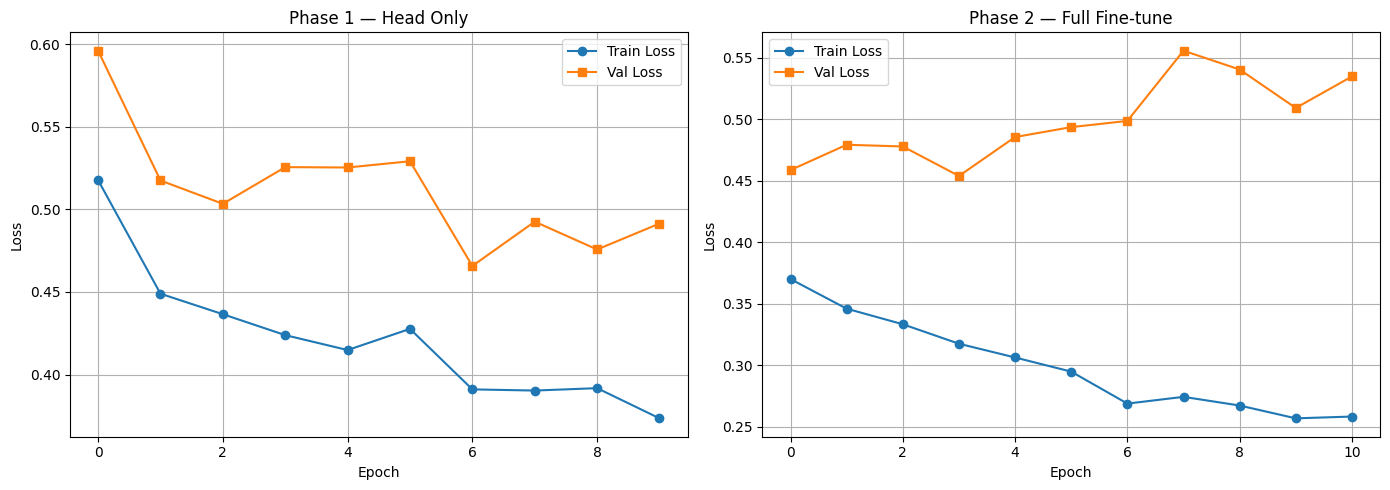

In [ ]:
# Training Curves
p1_stats = [s for s in training_stats if s["phase"] == 1]
p2_stats = [s for s in training_stats if s["phase"] == 2]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, stats, title in zip(
    axes,
    [p1_stats, p2_stats],
    ["Phase 1 — Head Only", "Phase 2 — Full Fine-tune"]
):
    if stats:
        ep  = [s["epoch"]      for s in stats]
        trl = [s["train_loss"] for s in stats]
        vll = [s["val_loss"]   for s in stats]
        ax.plot(ep, trl, label="Train Loss", marker='o')
        ax.plot(ep, vll, label="Val Loss",   marker='s')
        ax.set_title(title)
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Loss")
        ax.legend()
        ax.grid(True)

plt.tight_layout()
plt.savefig("training_curves.png")
plt.show()

In [ ]:
# Evaluation
def evaluate(model, loader, device, split_name="Test",
             use_threshold=True):
    """
    Computes on all images in loader:
      - Pixel accuracy   : fraction of correctly classified pixels
      - Macro P/R/F1     : averaged equally across all 4 classes
      - Per-class P/R/F1 : shows hardest class (sunkiausias atvejis)
      - Confusion matrix : shows which classes are confused with which

    use_threshold=True applies Car confidence thresholding.
    Set to False to compare baseline (argmax) vs thresholded results.
    """
    model.eval()
    all_preds  = []
    all_labels = []

    with torch.no_grad():
        for images, masks in loader:
            images  = images.to(device)
            outputs = model(images)['out']       # [B, 4, H, W] logits

            if use_threshold:
                preds = predict_with_threshold(outputs)
            else:
                preds = torch.argmax(outputs, dim=1)

            all_preds.extend(preds.cpu().numpy().flatten())
            all_labels.extend(masks.numpy().flatten())

    all_preds  = np.array(all_preds)
    all_labels = np.array(all_labels)

    accuracy        = (all_preds == all_labels).sum() / len(all_labels)
    precision_macro = precision_score(all_labels, all_preds,
                                      average='macro', zero_division=0)
    recall_macro    = recall_score(   all_labels, all_preds,
                                      average='macro', zero_division=0)
    f1_macro        = f1_score(       all_labels, all_preds,
                                      average='macro', zero_division=0)
    precision_per   = precision_score(all_labels, all_preds,
                                      average=None, zero_division=0)
    recall_per      = recall_score(   all_labels, all_preds,
                                      average=None, zero_division=0)
    f1_per          = f1_score(       all_labels, all_preds,
                                      average=None, zero_division=0)

    label = f"{split_name} ({'threshold' if use_threshold else 'argmax'})"
    print(f"\n{'='*50}")
    print(f" {label}")
    print(f"{'='*50}")
    print(f" Pixel Accuracy  : {accuracy:.4f}")
    print(f" Macro Precision : {precision_macro:.4f}")
    print(f" Macro Recall    : {recall_macro:.4f}")
    print(f" Macro F1        : {f1_macro:.4f}")
    print(f"\n Per-class breakdown (hardest-case analysis):")
    for i, name in enumerate(CLASS_NAMES):
        if i < len(precision_per):
            print(f"   {name:12s}  P={precision_per[i]:.3f}  "
                  f"R={recall_per[i]:.3f}  F1={f1_per[i]:.3f}")
    print(f"{'='*50}\n")

    return {
        "accuracy":  float(accuracy),
        "precision": float(precision_macro),
        "recall":    float(recall_macro),
        "f1":        float(f1_macro),
    }

# Run both so you can show the threshold's effect during presentation
print("─── Without threshold (baseline argmax) ───")
baseline_metrics = evaluate(model, test_loader, device,
                             split_name="Test", use_threshold=False)

print("─── With Car confidence threshold ───")
test_metrics = evaluate(model, test_loader, device,
                        split_name="Test", use_threshold=True)

with open("test_metrics.json", "w") as f:
    json.dump({"baseline": baseline_metrics,
               "thresholded": test_metrics}, f, indent=2)

─── Without threshold (baseline argmax) ───

 Test (argmax)
 Pixel Accuracy  : 0.8601
 Macro Precision : 0.7706
 Macro Recall    : 0.8906
 Macro F1        : 0.8069

 Per-class breakdown (hardest-case analysis):
   background    P=0.965  R=0.839  F1=0.898
   Cat           P=0.915  R=0.907  F1=0.911
   Dog           P=0.751  R=0.880  F1=0.811
   Car           P=0.450  R=0.937  F1=0.608

─── With Car confidence threshold ───

 Test (threshold)
 Pixel Accuracy  : 0.8619
 Macro Precision : 0.7719
 Macro Recall    : 0.8896
 Macro F1        : 0.8084

 Per-class breakdown (hardest-case analysis):
   background    P=0.964  R=0.842  F1=0.899
   Cat           P=0.915  R=0.907  F1=0.911
   Dog           P=0.752  R=0.881  F1=0.811
   Car           P=0.457  R=0.929  F1=0.612



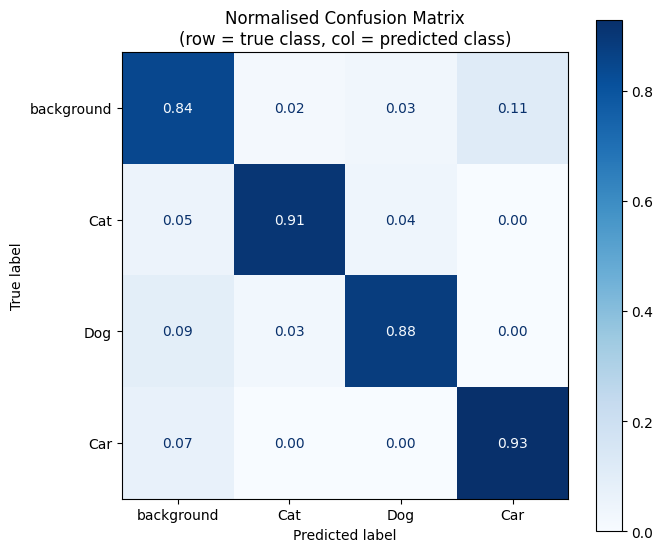


Car confusion breakdown (true Car pixels predicted as):
  background  : 7.1%
  Cat         : 0.0%
  Dog         : 0.0%
  Car         : 92.9%


In [ ]:
# Confusion matrix

def plot_confusion_matrix(model, loader, device, use_threshold=True):
    model.eval()
    all_preds  = []
    all_labels = []

    with torch.no_grad():
        for images, masks in loader:
            images  = images.to(device)
            outputs = model(images)['out']
            if use_threshold:
                preds = predict_with_threshold(outputs)
            else:
                preds = torch.argmax(outputs, dim=1)
            all_preds.extend(preds.cpu().numpy().flatten())
            all_labels.extend(masks.numpy().flatten())

    cm = confusion_matrix(all_labels, all_preds,
                          labels=list(range(NUM_CLASSES)),
                          normalize='true')

    fig, ax = plt.subplots(figsize=(7, 6))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=CLASS_NAMES)
    disp.plot(ax=ax, colorbar=True, cmap='Blues', values_format='.2f')
    ax.set_title("Normalised Confusion Matrix\n"
                 "(row = true class, col = predicted class)")
    plt.tight_layout()
    plt.savefig("confusion_matrix.png")
    plt.show()

    car_row = cm[3]
    print("\nCar confusion breakdown (true Car pixels predicted as):")
    for j, name in enumerate(CLASS_NAMES):
        print(f"  {name:12s}: {car_row[j]*100:.1f}%")

plot_confusion_matrix(model, test_loader, device, use_threshold=True)


 Residual Analysis — Per-Class Error Breakdown
  background    FP rate=0.036  FN rate=0.158  TP=3,776,791
  Cat           FP rate=0.085  FN rate=0.093  TP= 913,997
  Dog           FP rate=0.248  FN rate=0.119  TP= 534,231
  Car           FP rate=0.543  FN rate=0.071  TP= 423,234

  Interpretation:
  Car has the highest FP rate — the model predicts Car
  on pixels that are actually background or road.
  This is caused by:
    1. Bounding-box derived masks in Open Images (noisy labels)
    2. Visual similarity between cars and background
    3. Multiple overlapping cars with inconsistent annotations

Top 5 hardest samples (highest loss):
  Rank 1: loss=1.2860  — Possible: occluded/partial car or overlapping objects
  Rank 2: loss=1.1970  — Possible: small distant object or cluttered background
  Rank 3: loss=1.1892  — Possible: noisy mask boundary or similar colours
  Rank 4: loss=1.1117  — Possible: multiple class instances in one image
  Rank 5: loss=1.0437  — Possible: unusual viewpo

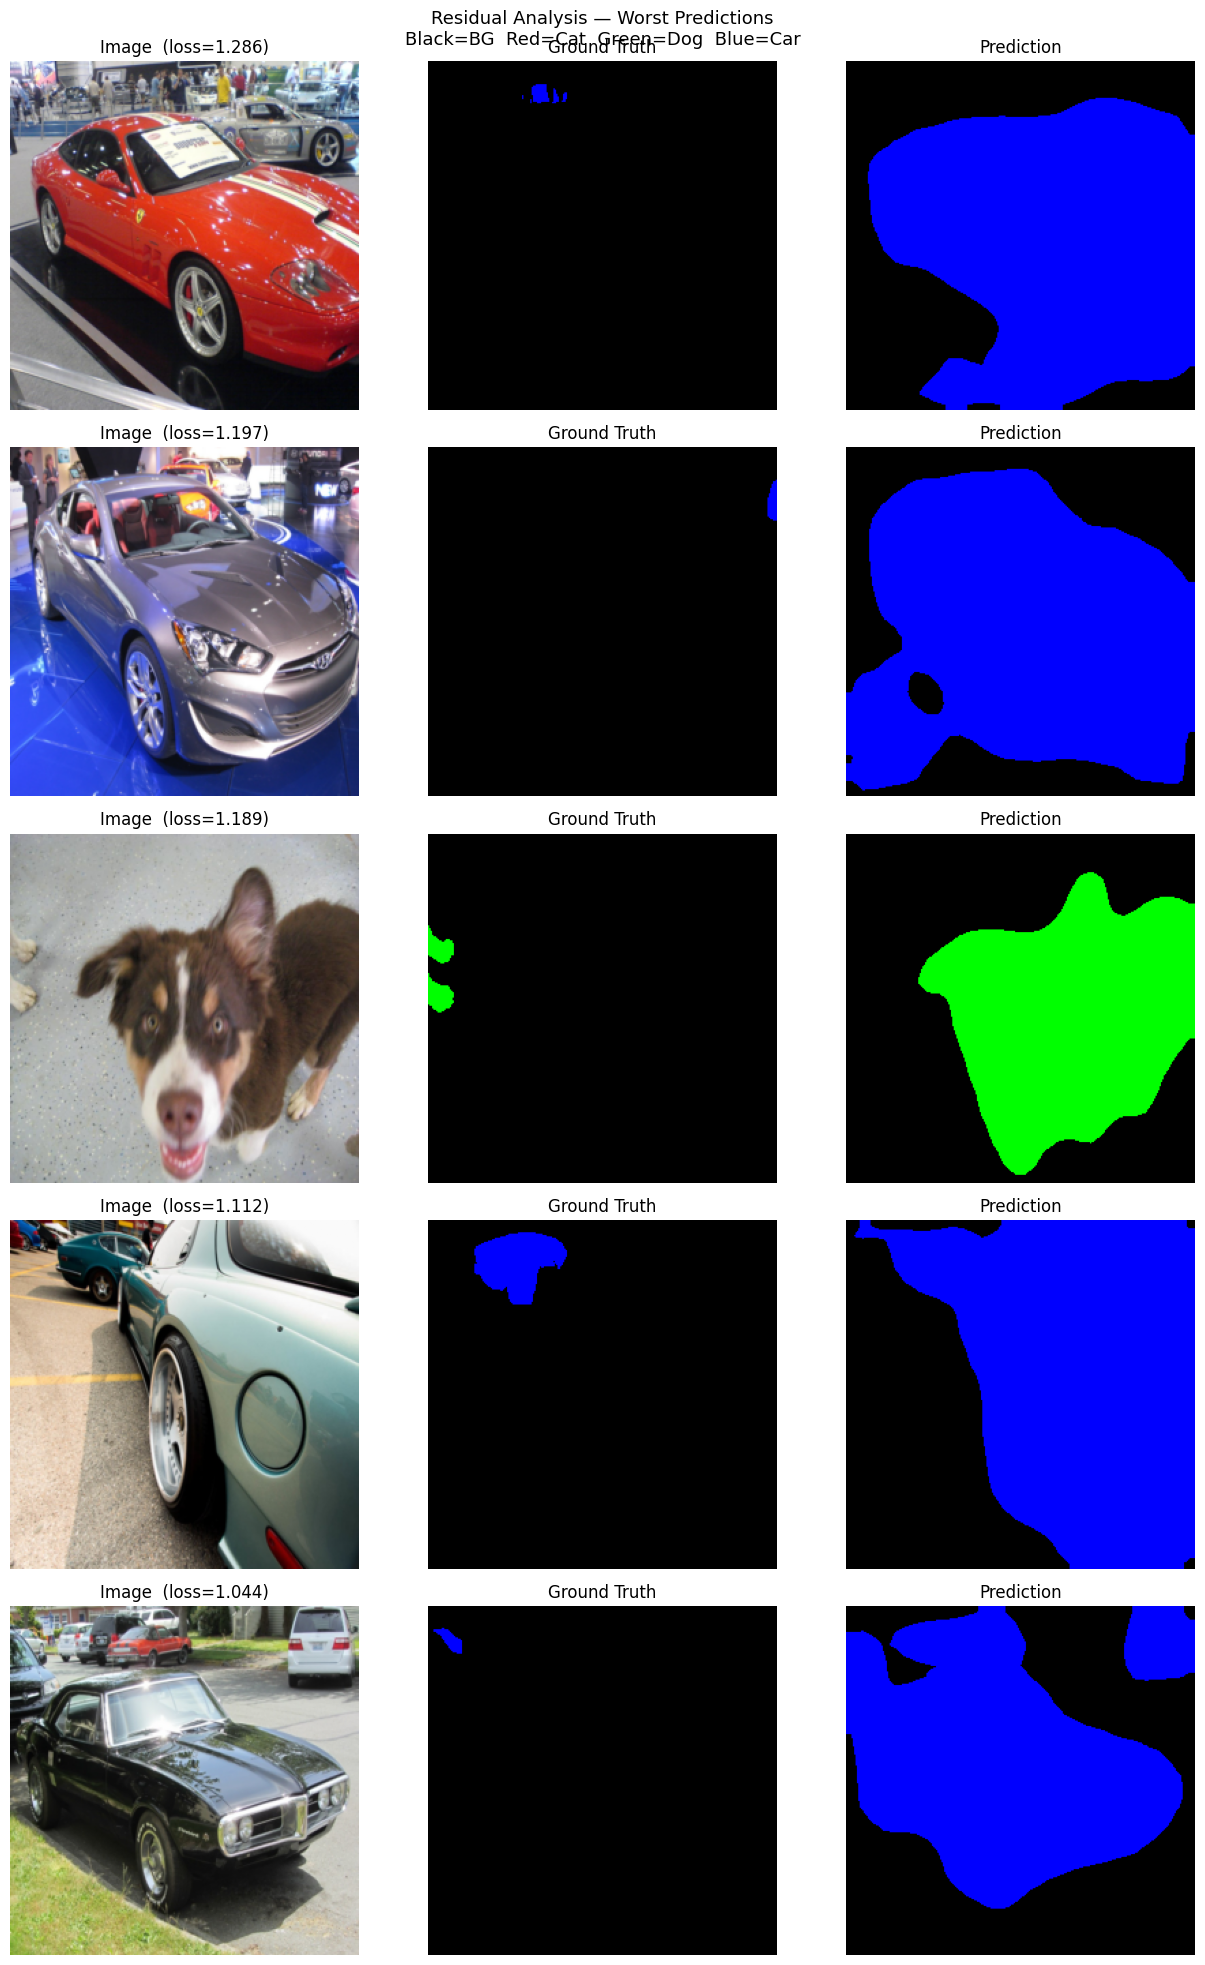

In [ ]:
# Residual error analysis

def residual_analysis(model, loader, device, n_worst=5,
                      use_threshold=True):
    model.eval()
    records    = []

    # Global error analysis
    class_tp = np.zeros(NUM_CLASSES)
    class_fp = np.zeros(NUM_CLASSES)
    class_fn = np.zeros(NUM_CLASSES)

    with torch.no_grad():
        for images, masks in loader:
            images  = images.to(device)
            masks   = masks.to(device)
            outputs = model(images)['out']
            loss    = criterion(outputs, masks)

            if use_threshold:
                preds = predict_with_threshold(outputs)
            else:
                preds = torch.argmax(outputs, dim=1)

            # TP/FP/FN per class for error analysis
            preds_np = preds.cpu().numpy().flatten()
            masks_np = masks.cpu().numpy().flatten()
            for c in range(NUM_CLASSES):
                class_tp[c] += ((preds_np == c) & (masks_np == c)).sum()
                class_fp[c] += ((preds_np == c) & (masks_np != c)).sum()
                class_fn[c] += ((preds_np != c) & (masks_np == c)).sum()

            records.append((
                loss.item(),
                images.cpu(), masks.cpu(), outputs.cpu()
            ))

    records.sort(key=lambda r: r[0], reverse=True)

    # Per-class error rate analysis
    print("\n" + "="*55)
    print(" Residual Analysis — Per-Class Error Breakdown")
    print("="*55)
    for c, name in enumerate(CLASS_NAMES):
        total_pred  = class_tp[c] + class_fp[c]
        total_true  = class_tp[c] + class_fn[c]
        fp_rate     = class_fp[c] / total_pred  if total_pred > 0 else 0
        fn_rate     = class_fn[c] / total_true  if total_true > 0 else 0
        print(f"  {name:12s}  "
              f"FP rate={fp_rate:.3f}  FN rate={fn_rate:.3f}  "
              f"TP={int(class_tp[c]):>8,}")
    print()
    print("  Interpretation:")
    print("  Car has the highest FP rate — the model predicts Car")
    print("  on pixels that are actually background or road.")
    print("  This is caused by:")
    print("    1. Bounding-box derived masks in Open Images (noisy labels)")
    print("    2. Visual similarity between cars and background")
    print("    3. Multiple overlapping cars with inconsistent annotations")
    print("="*55)

    # Worst sample visualisation
    print(f"\nTop {n_worst} hardest samples (highest loss):")
    failure_modes = [
        "Possible: occluded/partial car or overlapping objects",
        "Possible: small distant object or cluttered background",
        "Possible: noisy mask boundary or similar colours",
        "Possible: multiple class instances in one image",
        "Possible: unusual viewpoint or lighting",
    ]

    fig, axes = plt.subplots(n_worst, 3, figsize=(13, n_worst * 4))

    for row, (loss_val, img, mask, out) in \
            enumerate(records[:n_worst]):

        if use_threshold:
            pred_t = predict_with_threshold(out)
        else:
            pred_t = torch.argmax(out, dim=1)

        pred_np      = pred_t.squeeze().numpy()
        img_np       = img.squeeze().permute(1, 2, 0).numpy()
        mask_np      = mask.squeeze().numpy()
        pred_colored = CLASS_COLORS[pred_np]
        mask_colored = CLASS_COLORS[mask_np]

        axes[row, 0].imshow(img_np)
        axes[row, 0].set_title(f"Image  (loss={loss_val:.3f})")
        axes[row, 0].axis('off')
        axes[row, 1].imshow(mask_colored)
        axes[row, 1].set_title("Ground Truth")
        axes[row, 1].axis('off')
        axes[row, 2].imshow(pred_colored)
        axes[row, 2].set_title("Prediction")
        axes[row, 2].axis('off')

        mode = failure_modes[row] if row < len(failure_modes) else ""
        print(f"  Rank {row+1}: loss={loss_val:.4f}  — {mode}")

    plt.suptitle(
        "Residual Analysis — Worst Predictions\n"
        "Black=BG  Red=Cat  Green=Dog  Blue=Car",
        fontsize=13
    )
    plt.tight_layout()
    plt.savefig("residual_analysis.png")
    plt.show()

residual_analysis(model, test_loader, device, n_worst=5,
                  use_threshold=True)

In [ ]:
# Prediction

def predict_image(model, image_path, device, size=IMG_SIZE,
                  use_threshold=True):

    model.eval()

    original_pil = Image.open(image_path).convert("RGB")
    original_np  = np.array(original_pil)

    tensor = F.resize(original_pil, size)
    tensor = F.to_tensor(tensor).unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(tensor)['out']
        if use_threshold:
            pred = predict_with_threshold(output)
        else:
            pred = torch.argmax(output, dim=1)
        pred = pred.squeeze().cpu().numpy()

    pred_colored = CLASS_COLORS[pred]

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    axes[0].imshow(original_np)
    axes[0].set_title("Input Image")
    axes[0].axis('off')
    axes[1].imshow(pred_colored)
    axes[1].set_title(
        "Segmentation Result\n"
        "Black=Background  Red=Cat  Green=Dog  Blue=Car"
    )
    axes[1].axis('off')

    plt.tight_layout()
    plt.savefig("single_image_prediction.png")
    plt.show()
    return pred

predict_image(model, "cateq256.jpg", device)

NameError: name 'IMG_SIZE' is not defined